# 09_05: A taste of machine learning

In [1]:
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as pp

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# fix random number seed for repeatable computation
np.random.seed(43)

In [4]:
gm = pd.read_csv('gapminder.csv')

In [5]:
gm2023 = gm[gm.year == 2023]
gm2023.head()

,country,year,region,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita
207,Afghanistan,2023,Asia,41500000.0,64.0,94.760,4.84,1400.0
431,Albania,2023,Europe,2810000.0,77.3,99.199,1.35,16100.0
655,Algeria,2023,Africa,46200000.0,77.1,97.960,2.77,11400.0
866,Andorra,2023,Europe,80900.0,82.9,99.723,1.08,55700.0
1090,Angola,2023,Africa,36700000.0,65.9,93.300,5.12,5810.0


In [6]:
x = gm2023[['population', 'life_expectancy', 'age5_surviving', 'babies_per_woman', 'gdp_per_capita']]

In [7]:
y = gm2023['region'].astype('category')

In [8]:
z = y.cat.codes
z.head(10)

207     2
431     3
655     0
866     3
1090    0
1314    1
1538    1
1762    2
1986    4
2210    3
dtype: int8

In [9]:
x_train, x_test, z_train, z_test = train_test_split(x, z, test_size=0.3)

In [10]:
tree = DecisionTreeClassifier()

In [11]:
tree.fit(x_train, z_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [12]:
tree_pred = tree.predict(x_test)
tree_pred

array([0, 2, 2, 2, 3, 0, 1, 1, 0, 3, 0, 2, 2, 0, 1, 3, 2, 0, 2, 2, 0, 0,
       0, 0, 1, 0, 0, 1, 2, 0, 0, 1, 3, 3, 0, 0, 3, 2, 3, 1, 2, 2, 3, 0,
       0, 3, 0, 2, 0, 0, 0, 4, 3, 3, 0, 0, 3, 2, 3], dtype=int8)

In [13]:
pd.DataFrame({'label': y.cat.categories[z_test],
              'predicted': y.cat.categories[tree_pred]}).head(20)

,label,predicted
0,Africa,Africa
1,Europe,Asia
2,Asia,Asia
3,Africa,Asia
4,Europe,Europe
5,Africa,Africa
6,Asia,America
7,America,America
8,Africa,Africa
9,America,Europe


In [14]:
accuracy_score(z_test, tree_pred)

0.6949152542372882

In [15]:
np.sum(y.cat.categories[z_test] == y.cat.categories[tree_pred]) / len(z_test)

np.float64(0.6949152542372882)

In [16]:
print(classification_report(z_test, tree_pred, target_names=y.cat.categories))

              precision    recall  f1-score   support

      Africa       0.83      0.87      0.85        23
     America       0.43      0.50      0.46         6
        Asia       0.57      0.57      0.57        14
      Europe       0.69      0.75      0.72        12
     Oceania       1.00      0.25      0.40         4

    accuracy                           0.69        59
   macro avg       0.71      0.59      0.60        59
weighted avg       0.71      0.69      0.69        59



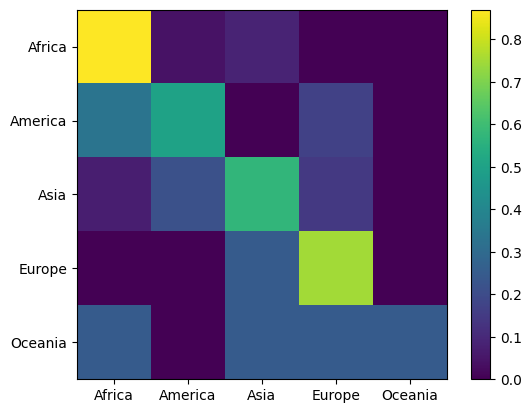

In [17]:
pp.imshow(confusion_matrix(z_test, tree_pred, normalize='true'))
pp.xticks(range(5), y.cat.categories); pp.yticks(range(5), y.cat.categories)
pp.colorbar();

In [18]:
forest = RandomForestClassifier()

In [19]:
forest.fit(x_train, z_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
forest_pred = forest.predict(x_test)

In [21]:
print(classification_report(z_test, forest_pred, target_names=y.cat.categories))

              precision    recall  f1-score   support

      Africa       0.91      0.87      0.89        23
     America       0.56      0.83      0.67         6
        Asia       0.50      0.50      0.50        14
      Europe       0.69      0.75      0.72        12
     Oceania       1.00      0.25      0.40         4

    accuracy                           0.71        59
   macro avg       0.73      0.64      0.64        59
weighted avg       0.74      0.71      0.71        59



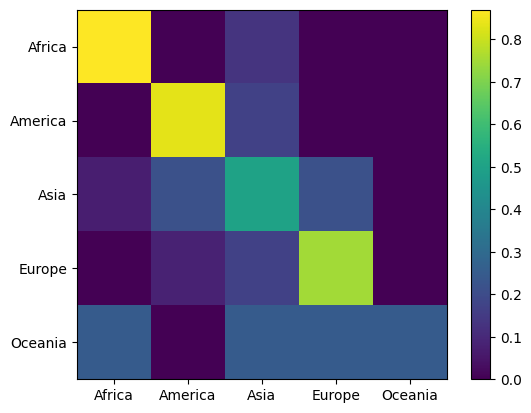

In [22]:
pp.imshow(confusion_matrix(z_test, forest_pred, normalize='true'))
pp.xticks(range(5), y.cat.categories); pp.yticks(range(5), y.cat.categories)
pp.colorbar();